In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [33]:
from cycler import cycler
#line_cycler   = (cycler(color=["#FF2525", "#90C4FF", "#009E73", "#0072B2", "#D55E00",  "#F0E442", "#E69F00"]) +
#                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))
line_cycler   = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))

marker_cycler = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["none", "none", "none", "none", "none", "none", "none"]) +
                 cycler(marker=["4", "2", "3", "1", "+", "x", "."]))

In [2]:
fp32_path = "../../../full_precision/memorization/experiments"

# Attack mem ep

In [3]:
expath = '../attack_mem_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_ep.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_ep/attack_mem_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '15b_ep0', '15b_ep0_em', '15b_ep0_bleu', '15b_ep0_meteor',
       '15b_ep0_rougeL', '15b_ep1', '15b_ep1_em', '15b_ep1_bleu',
       '15b_ep1_meteor', '15b_ep1_rougeL', '15b_ep2', '15b_ep2_em',
       '15b_ep2_bleu', '15b_ep2_meteor', '15b_ep2_rougeL', '15b_ep3',
       '15b_ep3_em', '15b_ep3_bleu', '15b_ep3_meteor', '15b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [4]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'15b_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_fp32_absolute = pd.DataFrame(mean_data, index=eps)
ep_fp32_absolute

,em,bleu,meteor,rougeL
ep0,0.300,57.590960,0.630527,0.624876
ep1,0.549,75.689394,0.780136,0.782796
ep2,0.567,76.090178,0.783977,0.783531
ep3,0.609,77.444160,0.801378,0.796632


In [5]:
# With the baseline
first = ep_fp32_absolute.iloc[0]

ep_fp32_baseline = ep_fp32_absolute.subtract(first)
ep_fp32_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.249,18.098435,0.149609,0.157920
ep2,0.267,18.499219,0.153450,0.158654
ep3,0.309,19.853200,0.170851,0.171755


### bf16

In [6]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'bf16_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_bf16_absolute = pd.DataFrame(mean_data, index=eps)
ep_bf16_absolute

,em,bleu,meteor,rougeL
ep0,0.302,57.614924,0.628937,0.624452
ep1,0.550,75.717031,0.780031,0.782793
ep2,0.571,76.069976,0.784100,0.782830
ep3,0.610,77.305064,0.800632,0.795634


In [7]:
# With the baseline
first = ep_bf16_absolute.iloc[0]

ep_bf16_baseline = ep_bf16_absolute.subtract(first)
ep_bf16_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.248,18.102107,0.151093,0.158341
ep2,0.269,18.455052,0.155162,0.158378
ep3,0.308,19.690140,0.171695,0.171181


## int8

In [8]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'i8_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_i8_absolute = pd.DataFrame(mean_data, index=eps)
ep_i8_absolute

,em,bleu,meteor,rougeL
ep0,0.297,57.121291,0.628467,0.620365
ep1,0.540,75.558972,0.780072,0.781780
ep2,0.563,75.850500,0.781918,0.781618
ep3,0.610,77.380866,0.801665,0.796619


In [9]:
# With the baseline
first = ep_i8_absolute.iloc[0]

ep_i8_baseline = ep_i8_absolute.subtract(first)
ep_i8_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.243,18.437681,0.151605,0.161415
ep2,0.266,18.729209,0.153452,0.161253
ep3,0.313,20.259575,0.173198,0.176254


## i4

In [10]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'i4_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_i4_absolute = pd.DataFrame(mean_data, index=eps)
ep_i4_absolute

,em,bleu,meteor,rougeL
ep0,0.248,53.988420,0.605747,0.596535
ep1,0.522,74.691274,0.767346,0.773100
ep2,0.550,75.522919,0.781693,0.779965
ep3,0.583,76.788414,0.795136,0.790262


In [11]:
# With the baseline
first = ep_i4_absolute.iloc[0]

ep_i4_baseline = ep_i4_absolute.subtract(first)
ep_i4_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.274,20.702854,0.161599,0.176565
ep2,0.302,21.534500,0.175947,0.183430
ep3,0.335,22.799994,0.189390,0.193727


## Visuals


In [12]:
df_ep_mem_plot = pd.DataFrame({ 'fp32': ep_fp32_baseline['em'],
                                'bf16': ep_bf16_baseline['em'],
                               'i8': ep_i8_baseline['em'],
                               'i4': ep_i4_baseline['em']})
df_ep_mem_plot

,fp32,bf16,i8,i4
ep0,0.000,0.000,0.000,0.000
ep1,0.249,0.248,0.243,0.274
ep2,0.267,0.269,0.266,0.302
ep3,0.309,0.308,0.313,0.335


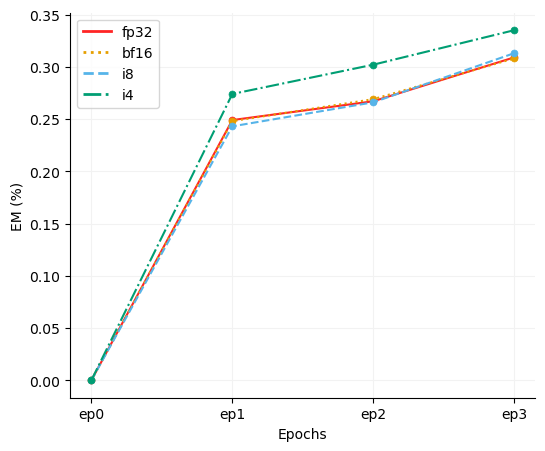

In [17]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], label=label, 
            color=colors[i], linestyle=linestyles[i], marker=markers[i], 
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Epochs')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_mem_ep.pdf', format='pdf')

# Attack mem dedup

In [34]:
expath = '../attack_mem_dedup'
df_d1 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_1.parquet'))
df_d1_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_1.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d1', '15b_ep0_d1_em', '15b_ep0_d1_bleu',
       '15b_ep0_d1_meteor', '15b_ep0_d1_rougeL', '15b_ep3_d1', '15b_ep3_d1_em',
       '15b_ep3_d1_bleu', '15b_ep3_d1_meteor', '15b_ep3_d1_rougeL']]

merged_df_d1 = pd.merge(df_d1, df_d1_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


df_d2 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_2.parquet'))
df_d2_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_2.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d2', '15b_ep0_d2_em', '15b_ep0_d2_bleu',
       '15b_ep0_d2_meteor', '15b_ep0_d2_rougeL', '15b_ep3_d2', '15b_ep3_d2_em',
       '15b_ep3_d2_bleu', '15b_ep3_d2_meteor', '15b_ep3_d2_rougeL']]

merged_df_d2 = pd.merge(df_d2, df_d2_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

df_d3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_3.parquet'))
df_d3_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_3.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d3', '15b_ep0_d3_em', '15b_ep0_d3_bleu',
       '15b_ep0_d3_meteor', '15b_ep0_d3_rougeL', '15b_ep3_d3', '15b_ep3_d3_em',
       '15b_ep3_d3_bleu', '15b_ep3_d3_meteor', '15b_ep3_d3_rougeL']]

merged_df_d3 = pd.merge(df_d3, df_d3_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

df_dg3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_g3.parquet'))
df_dg3_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_g3.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_dg3', '15b_ep0_dg3_em', '15b_ep0_dg3_bleu',
       '15b_ep0_dg3_meteor', '15b_ep0_dg3_rougeL', '15b_ep3_dg3', '15b_ep3_dg3_em',
       '15b_ep3_dg3_bleu', '15b_ep3_dg3_meteor', '15b_ep3_dg3_rougeL']]

merged_df_dg3 = pd.merge(df_dg3, df_dg3_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

dfs = [merged_df_d1, merged_df_d2, merged_df_d3, merged_df_dg3]


## fp32

In [35]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'15b_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_fp32_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_fp32_absolute

,em,bleu,meteor,rougeL
d1,0.075,47.571063,0.551008,0.521291
d2,0.352,69.480422,0.735116,0.722802
d3,0.544,83.215179,0.859007,0.853429
dg3,0.609,77.447960,0.801344,0.796660


In [40]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'15b_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_fp32_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_fp32_baseline = dedup_fp32_absolute.subtract(dedup_fp32_ep0)

dedup_fp32_baseline

,em,bleu,meteor,rougeL
d1,0.052,10.932447,0.090406,0.099935
d2,0.277,24.443996,0.215197,0.221894
d3,0.417,38.548428,0.324719,0.347771
dg3,0.310,19.865729,0.170740,0.171861


## bf16

In [36]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'bf16_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_bf16_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_bf16_absolute

,em,bleu,meteor,rougeL
d1,0.078,47.581936,0.551593,0.521802
d2,0.352,69.371235,0.733780,0.721204
d3,0.545,83.467980,0.860393,0.855988
dg3,0.610,77.305064,0.800632,0.795634


In [41]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'bf16_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_bf16_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_bf16_baseline = dedup_bf16_absolute.subtract(dedup_bf16_ep0)

dedup_bf16_baseline

,em,bleu,meteor,rougeL
d1,0.055,10.655141,0.090650,0.097562
d2,0.277,24.699686,0.217790,0.223314
d3,0.418,38.660802,0.325104,0.348880
dg3,0.308,19.690140,0.171695,0.171181


## i8

In [37]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i8_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i8_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_i8_absolute

,em,bleu,meteor,rougeL
d1,0.077,47.782649,0.553704,0.522495
d2,0.350,69.166089,0.732211,0.718972
d3,0.541,83.070264,0.858024,0.852527
dg3,0.610,77.380866,0.801665,0.796619


In [42]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i8_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i8_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_i8_baseline = dedup_i8_absolute.subtract(dedup_i8_ep0)

dedup_i8_baseline

,em,bleu,meteor,rougeL
d1,0.053,11.222983,0.096387,0.102009
d2,0.276,24.247739,0.215184,0.220578
d3,0.415,38.770142,0.325614,0.348131
dg3,0.313,20.259575,0.173198,0.176254


## i4

In [38]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i4_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i4_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_i4_absolute

,em,bleu,meteor,rougeL
d1,0.079,47.072731,0.547326,0.516718
d2,0.331,67.705845,0.722305,0.706458
d3,0.512,81.356818,0.841716,0.837033
dg3,0.583,76.788414,0.795136,0.790262


In [43]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i4_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i4_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_i4_baseline = dedup_i4_absolute.subtract(dedup_i4_ep0)

dedup_i4_baseline

,em,bleu,meteor,rougeL
d1,0.056,10.827673,0.090239,0.097401
d2,0.258,22.782354,0.207810,0.205721
d3,0.393,37.390838,0.314389,0.338320
dg3,0.335,22.799994,0.189390,0.193727


## Visuals

In [44]:
df_dedup_mem_plot = pd.DataFrame({'fp32': dedup_fp32_baseline['em'],
                                  'bf16': dedup_bf16_baseline['em'],
                                  'i8': dedup_i8_baseline['em'],
                                  'i4': dedup_i4_baseline['em'],
                                  })
df_dedup_mem_plot

,fp32,bf16,i8,i4
d1,0.052,0.055,0.053,0.056
d2,0.277,0.277,0.276,0.258
d3,0.417,0.418,0.415,0.393
dg3,0.310,0.308,0.313,0.335


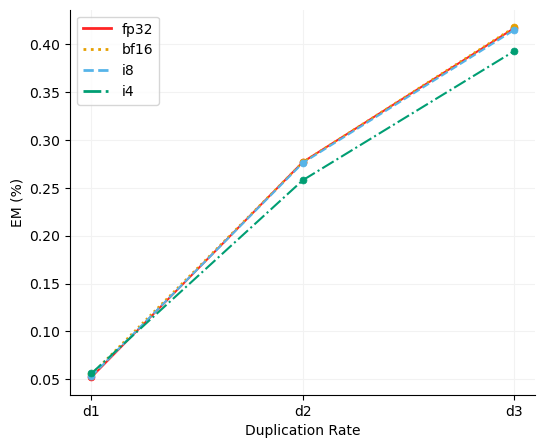

In [53]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_dedup_mem_plot.loc[["d1", "d2", "d3"]].index, df_dedup_mem_plot.loc[["d1", "d2", "d3"]][label],
            label=label,
            color=colors[i], linestyle=linestyles[i], marker=markers[i],
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Duplication Rate')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_mem_dedup.pdf', format='pdf')

# Attack mem plen (todo)